In [1]:
import pandas as pd
import numpy as np

In [15]:
df = pd.read_csv(
    "../data/raw/complaints.csv",
    nrows=450000
)

C:\Users\samiy\AppData\Local\Temp\ipykernel_41676\3114089771.py:1: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [22]:
print(df.shape)
df.head()

(20295, 7)


,Product,Issue,Sub-issue,Consumer complaint narrative,Company,State,Date received
76,Credit reporting or other personal consumer re...,Problem with fraud alerts or security freezes,NaN,XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX Apt XX...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,2025-03-06
359,Credit reporting or other personal consumer re...,Incorrect information on your report,Information is missing that should be on the r...,Subject : Dispute of Unauthorized Hard Inquiri...,Experian Information Solutions Inc.,FL,2025-02-26
11499,Mortgage,Applying for a mortgage or refinancing an exis...,Changes in loan terms during the application p...,I signed a purchase agreement with Lennar Corp...,"Lennar Financial Services, LLC",IL,2025-06-15
11973,Credit reporting or other personal consumer re...,Improper use of your report,Reporting company used your report improperly,"After checking my report, I found numerous acc...","Fidelity National Information Services, Inc. (...",FL,2025-06-14
12237,Credit card,Getting a credit card,Card opened without my consent or knowledge,A XXXX XXXX card was opened under my name by a...,"CITIBANK, N.A.",TX,2025-06-13


In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 20295 entries, 76 to 449999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Product                       20295 non-null  str  
 1   Issue                         20295 non-null  str  
 2   Sub-issue                     19697 non-null  str  
 3   Consumer complaint narrative  20295 non-null  str  
 4   Company                       20295 non-null  str  
 5   State                         20211 non-null  str  
 6   Date received                 20295 non-null  str  
dtypes: str(7)
memory usage: 25.5 MB


In [25]:
df["Date received"] = pd.to_datetime(df["Date received"], errors="coerce")

In [26]:
df["Date received"].isna().sum()

np.int64(0)

In [29]:
df["Product"].value_counts()

Product
Credit reporting or other personal consumer reports                             14758
Debt collection                                                                  1946
Credit card                                                                      1100
Checking or savings account                                                      1085
Mortgage                                                                          410
Money transfer, virtual currency, or money service                                276
Vehicle loan or lease                                                             225
Student loan                                                                      213
Payday loan, title loan, personal loan, or advance loan                           149
Prepaid card                                                                       66
Debt or credit management                                                          48
Credit reporting, credit repair services, or o

In [36]:
product_counts = df["Product"].value_counts()

print(product_counts)

Product
Credit reporting or other personal consumer reports                             14758
Debt collection                                                                  1946
Credit card                                                                      1100
Checking or savings account                                                      1085
Mortgage                                                                          410
Money transfer, virtual currency, or money service                                276
Vehicle loan or lease                                                             225
Student loan                                                                      213
Payday loan, title loan, personal loan, or advance loan                           149
Prepaid card                                                                       66
Debt or credit management                                                          48
Credit reporting, credit repair services, or o

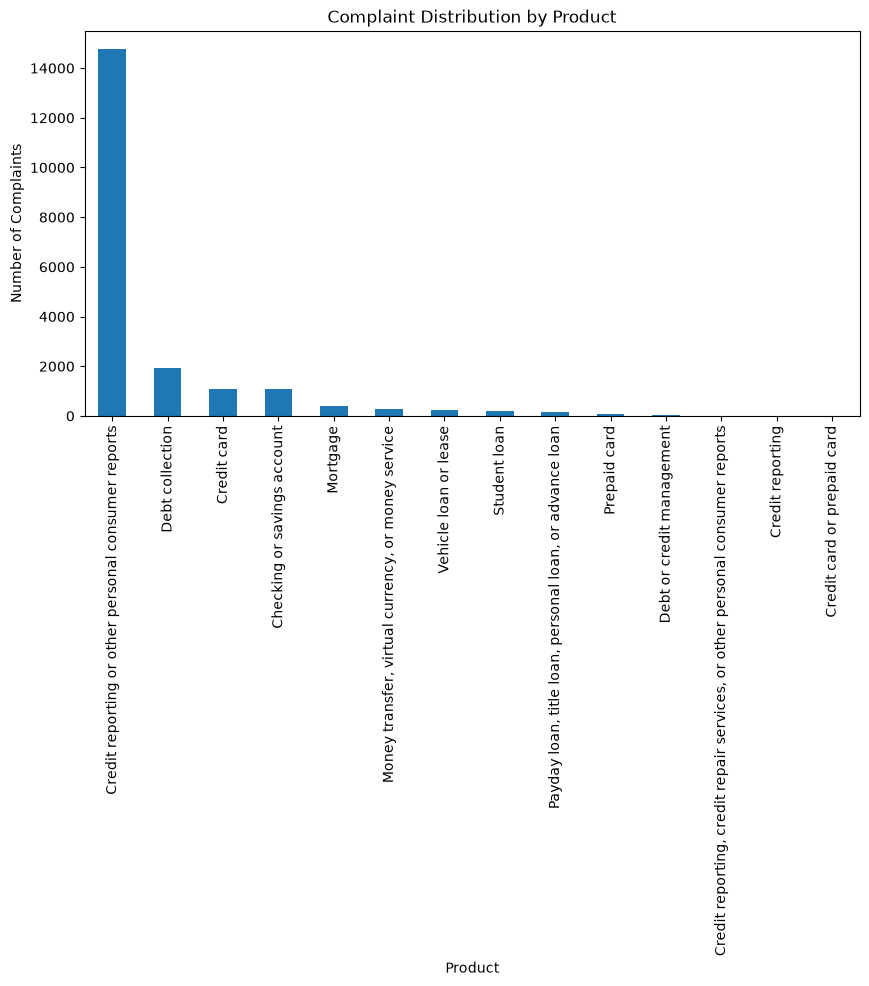

In [37]:
import matplotlib.pyplot as plt

product_counts.plot(kind="bar", figsize=(10,5))
plt.title("Complaint Distribution by Product")
plt.xlabel("Product")
plt.ylabel("Number of Complaints")
plt.show()

In [33]:
df["Company"].value_counts().head(10)

Company
Experian Information Solutions Inc.       5896
TRANSUNION INTERMEDIATE HOLDINGS, INC.    4272
EQUIFAX, INC.                             3352
CITIBANK, N.A.                             669
WELLS FARGO & COMPANY                      559
BANK OF AMERICA, NATIONAL ASSOCIATION      264
U.S. BANCORP                               229
CAPITAL ONE FINANCIAL CORPORATION          192
SYNCHRONY FINANCIAL                        185
Shellpoint Partners, LLC                   134
Name: count, dtype: int64

In [38]:
df["word_count"] = (
    df["Consumer complaint narrative"]
    .astype(str)
    .str.split()
    .str.len()
)

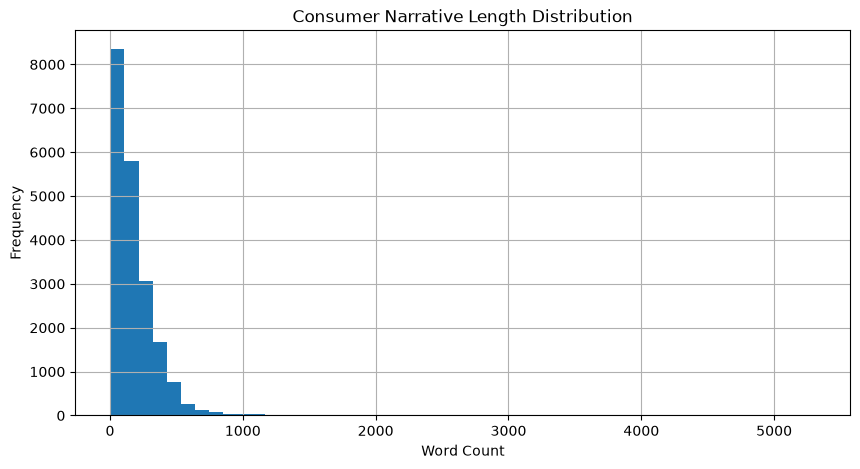

In [39]:
plt.figure(figsize=(10,5))

df["word_count"].hist(bins=50)

plt.title("Consumer Narrative Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [40]:
df[df["word_count"] < 20][
    ["Consumer complaint narrative", "word_count"]
].head()

,Consumer complaint narrative,word_count
17670,"Ongoing payment situation with Best Buy, my pa...",18
33288,CHARGE-OFF DEBT IS TAXABLE INCOME AND CAN NO L...,19
34384,"Upon reviewing my credit report, I have identi...",18
35451,"Upon reviewing my credit report, I have identi...",18
35747,"Upon reviewing my credit report, I have identi...",18


In [41]:
df.sort_values(
    "word_count",
    ascending=False
)[
    ["word_count", "Consumer complaint narrative"]
].head()

,word_count,Consumer complaint narrative
315598,5307,Summary of Demand Please take notice that I he...
261627,4835,Subject : Formal Complaint : Deceptive Financi...
125869,4626,XXXX XXXX XXXX XXXX. \n\nXXXX XXXX XXXX. \n\nX...
407775,4590,**Consumer Financial Protection Bureau ( CFPB ...
340591,3456,To whom it may concern : Consumer Financial Pr...


<Axes: xlabel='Date received'>

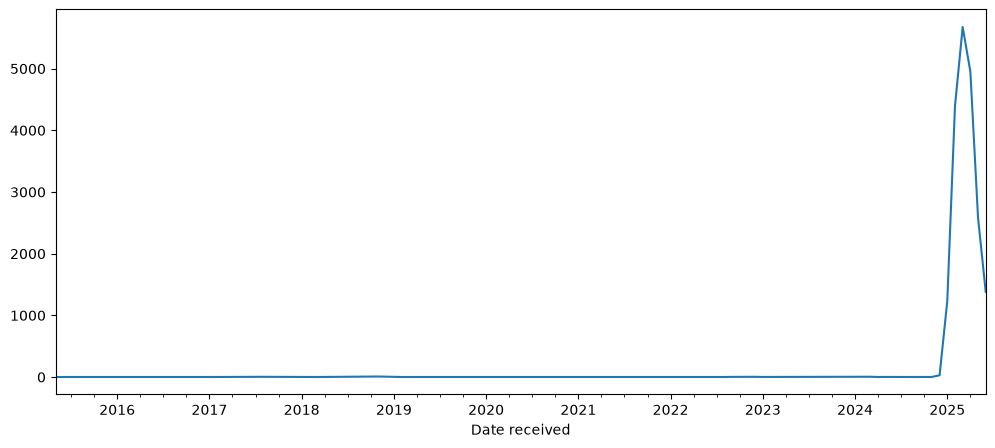

In [35]:
monthly = df.groupby(df["Date received"].dt.to_period("M")).size()

monthly.plot(figsize=(12,5))

In [51]:
target_products = [
    "Credit card",
    "Checking or savings account",
    "Money transfer, virtual currency, or money service",
    "Payday loan, title loan, personal loan, or advance loan"
]

filtered_df = df[df["Product"].isin(target_products)].copy()

print(filtered_df.shape)
print(filtered_df["Product"].value_counts())

(2610, 9)
Product
Credit card                                                1100
Checking or savings account                                1085
Money transfer, virtual currency, or money service          276
Payday loan, title loan, personal loan, or advance loan     149
Name: count, dtype: int64


In [52]:
filtered_df = filtered_df[
    filtered_df["Consumer complaint narrative"].notna()
]

In [53]:
filtered_df["clean_text"] = (
    filtered_df["Consumer complaint narrative"]
    .str.lower()
)

In [54]:
import re

def remove_special_chars(text):
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

filtered_df["clean_text"] = (
    filtered_df["clean_text"]
    .apply(remove_special_chars)
)

In [55]:
boilerplate_patterns = [
    r"i am writing to file a complaint",
    r"i would like to file a complaint",
    r"this complaint concerns"
]

def remove_boilerplate(text):
    for pattern in boilerplate_patterns:
        text = re.sub(pattern, "", text)
    return text.strip()

filtered_df["clean_text"] = (
    filtered_df["clean_text"]
    .apply(remove_boilerplate)
)

In [56]:
filtered_df["clean_text"] = (
    filtered_df["clean_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [57]:
filtered_df[
    [
        "Consumer complaint narrative",
        "clean_text"
    ]
].head()

,Consumer complaint narrative,clean_text
12237,A XXXX XXXX card was opened under my name by a...,a xxxx xxxx card was opened under my name by a...
12532,I made the mistake of using my wellsfargo debi...,i made the mistake of using my wellsfargo debi...
13280,"Dear CFPB, I have a secured credit card with c...",dear cfpb i have a secured credit card with ci...
13506,I have a Citi rewards cards. The credit balanc...,i have a citi rewards cards the credit balance...
13955,b'I am writing to dispute the following charge...,b i am writing to dispute the following charge...


In [58]:
filtered_df.shape

(2610, 10)

In [59]:
with_narrative = filtered_df["Consumer complaint narrative"].notna().sum()
without_narrative = filtered_df["Consumer complaint narrative"].isna().sum()

print(with_narrative, without_narrative)

2610 0


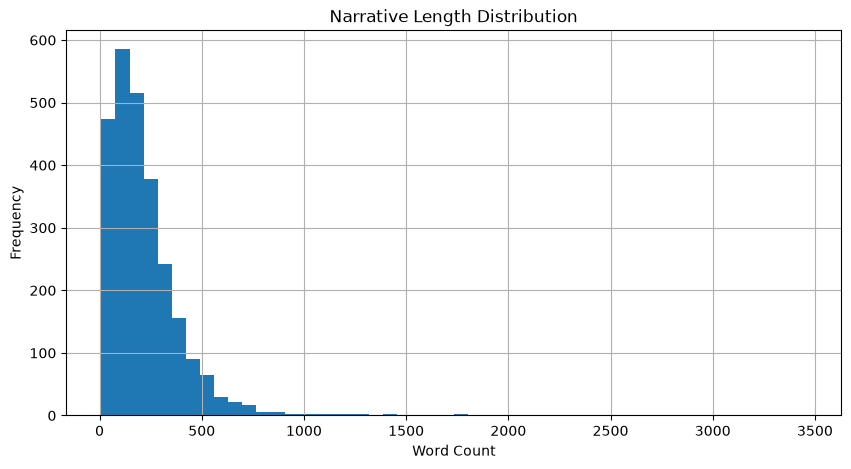

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
filtered_df["word_count"].hist(bins=50)
plt.title("Narrative Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [61]:
filtered_df.to_csv(
    "../data/processed/cfpb_cleaned_financial_products.csv",
    index=False
)

In [ ]:
filtered_df["word_count"].describe()

count    2610.000000
mean      220.231034
std       200.814161
min         9.000000
25%       100.000000
50%       177.000000
75%       286.000000
max      3456.000000
Name: word_count, dtype: float64

The consumer complaint narratives show a highly variable length distribution, with an average of 220 words and a median of 177 words. While most complaints are moderately detailed, there exist extreme outliers reaching over 3000 words. This variation highlights the need for a chunking strategy in downstream retrieval-based models to ensure long documents are properly segmented for embedding generation.